# Ejercicio: Clustering con reducción de dimensionalidad

In [1]:
# Importar las librerias necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

In [2]:
# Cargar los datos
data = pd.read_csv('train.csv') 
data.shape

(114000, 21)

In [3]:
# Visualizar las primeras filas del dataset
data.head(10)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


## Limpieza del dataset

In [4]:
# Eliminar columnas irrelevantes para el objeto de análisis
data = data.drop(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'duration_ms', 'popularity'], axis=1)

In [5]:
# Comprobar valor únicos
n_unique = data.nunique()
print(n_unique)

# Eliminar columnas con poca varianza
data = data.drop(['explicit', 'key', 'mode', 'time_signature', 'track_genre'], axis=1)

explicit                2
danceability         1174
energy               2083
key                    12
loudness            19480
mode                    2
speechiness          1489
acousticness         5061
instrumentalness     5346
liveness             1722
valence              1790
tempo               45653
time_signature          5
track_genre           114
dtype: int64


In [6]:
# Verificar si hay valores nulos
print(data.isnull().sum())

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64


In [7]:
# Información de las variables restantes objeto de análisis
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   danceability      114000 non-null  float64
 1   energy            114000 non-null  float64
 2   loudness          114000 non-null  float64
 3   speechiness       114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   instrumentalness  114000 non-null  float64
 6   liveness          114000 non-null  float64
 7   valence           114000 non-null  float64
 8   tempo             114000 non-null  float64
dtypes: float64(9)
memory usage: 7.8 MB


## Feature engineering y normalización de variables

In [8]:
# 1. Definir la función de ingeniería de características
def feature_engineering(df):
    df_eng = df.copy()
    
    # --- A. MOOD QUADRANT ---
    # 0.0 = Sad, 1.0 = Calm, 2.0 = Angry, 3.0 = Happy
    conditions = [
        (df_eng['valence'] < 0.5) & (df_eng['energy'] < 0.5),   # Sad
        (df_eng['valence'] >= 0.5) & (df_eng['energy'] < 0.5),  # Calm
        (df_eng['valence'] < 0.5) & (df_eng['energy'] >= 0.5),  # Angry
        (df_eng['valence'] >= 0.5) & (df_eng['energy'] >= 0.5)  # Happy
    ]
    choices = [0.0, 1.0, 2.0, 3.0]
    
    df_eng['mood_quadrant'] = np.select(conditions, choices, default=-1.0)
    
    # --- B. TRACK INTENSITY CORREGIDO ---
    scaler_temp = MinMaxScaler()
    loudness_0_to_1 = scaler_temp.fit_transform(df_eng[['loudness']])
    df_eng['track_intensity'] = loudness_0_to_1.flatten() * df_eng['energy']
    
    # --- C. ACOUSTIC VECTOR ---
    df_eng['acoustic_vector'] = df_eng['acousticness'] - df_eng['energy']
    
    return df_eng

# A. Aplicar Feature Engineering
data_engineered = feature_engineering(data)

# B. Identificar columnas
# 1. Identificamos TODAS las numéricas
all_numeric_cols = data_engineered.select_dtypes(include=[np.number]).columns

# 2. Definimos cuáles NO queremos escalar (porque son categorías codificadas)
cols_exclude_scaling = ['mood_quadrant'] 

# 3. Definimos las que SÍ vamos a escalar (Restamos las excluidas del total)
# Usamos lista por comprensión para mantener el orden y evitar errores si hay índices
cols_to_scale = [col for col in all_numeric_cols if col not in cols_exclude_scaling]

# C. Normalización (StandardScaler)
scaler = StandardScaler()

# Escalamos SOLO las variables continuas
data_scaled_numeric = pd.DataFrame(
    scaler.fit_transform(data_engineered[cols_to_scale]), 
    columns=cols_to_scale,
    index=data_engineered.index # Importante mantener el índice para concatenar bien
)

# D. Unir todo de nuevo
# Concatenamos:
# 1. Las variables continuas ya escaladas (data_scaled_numeric)
# 2. La variable mood_quadrant original (sin escalar)
other_cols = data_engineered.drop(columns=cols_to_scale)

data = pd.concat([data_scaled_numeric, other_cols], axis=1)

print("Proceso completado.")
print(data.head())

Proceso completado.
   danceability    energy  loudness  speechiness  acousticness  \
0      0.629244 -0.717148  0.300828     0.551848     -0.850202   
1     -0.845908 -1.889980 -1.784744    -0.078993      1.831732   
2     -0.742186 -1.122669 -0.293288    -0.273826     -0.315499   
3     -1.733304 -2.312994 -2.039252    -0.457309      1.774593   
4      0.295030 -0.788711 -0.282750    -0.303145      0.463399   

   instrumentalness  liveness   valence     tempo  track_intensity  \
0         -0.504109  0.758743  0.929306 -1.141863        -0.641308   
1         -0.504094 -0.591211 -0.798690 -1.489717        -1.835853   
2         -0.504112 -0.507167 -1.365688 -1.528312        -1.093481   
3         -0.503883 -0.428376 -1.276974  1.987859        -2.127993   
4         -0.504112 -0.686285 -1.184403 -0.073348        -0.813497   

   acoustic_vector  mood_quadrant  
0        -0.187890            1.0  
1         1.991276            0.0  
2         0.325870            0.0  
3         2.151757

In [9]:
# Visualizar las primeras filas del dataset
data.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_intensity,acoustic_vector,mood_quadrant
0,0.629244,-0.717148,0.300828,0.551848,-0.850202,-0.504109,0.758743,0.929306,-1.141863,-0.641308,-0.187890,1.0
1,-0.845908,-1.889980,-1.784744,-0.078993,1.831732,-0.504094,-0.591211,-0.798690,-1.489717,-1.835853,1.991276,0.0
2,-0.742186,-1.122669,-0.293288,-0.273826,-0.315499,-0.504112,-0.507167,-1.365688,-1.528312,-1.093481,0.325870,0.0
3,-1.733304,-2.312994,-2.039252,-0.457309,1.774593,-0.503883,-0.428376,-1.276974,1.987859,-2.127993,2.151757,0.0
4,0.295030,-0.788711,-0.282750,-0.303145,0.463399,-0.504112,-0.686285,-1.184403,-0.073348,-0.813497,0.647200,0.0


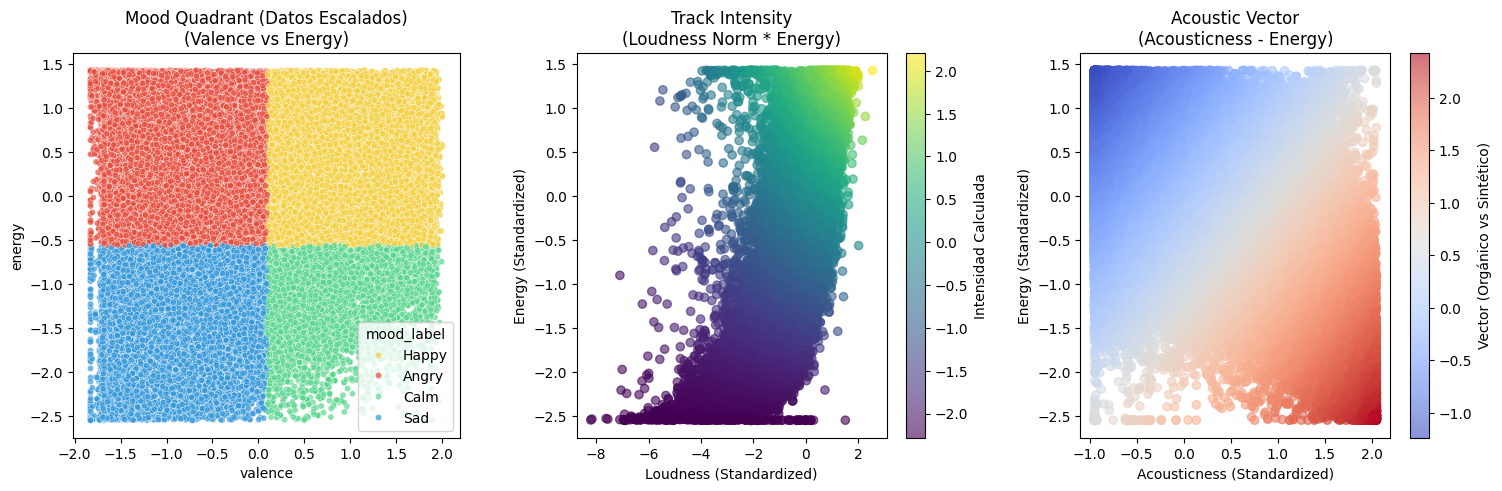

In [10]:
# 1. Preparación para graficar
# Creamos un mapeo temporal para que la leyenda muestre nombres y no números
mood_labels = {0.0: 'Sad', 1.0: 'Calm', 2.0: 'Angry', 3.0: 'Happy'}
colors = {'Happy': '#F4D03F', 'Angry': '#E74C3C', 'Calm': '#58D68D', 'Sad': '#3498DB'}

# Creamos una columna temporal de texto solo para el gráfico (para que la leyenda sea legible)
data_viz = data.copy()
data_viz['mood_label'] = data_viz['mood_quadrant'].map(mood_labels)

# Configuración del plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3) # Espacio entre gráficos

# --- GRÁFICO 1: MOOD QUADRANT ---
sns.scatterplot(
    data=data_viz, 
    x='valence', 
    y='energy', 
    hue='mood_label', 
    palette=colors,
    hue_order=['Happy', 'Angry', 'Calm', 'Sad'], # Para forzar el orden en la leyenda
    ax=axes[0],
    s=20, alpha=0.7
)
axes[0].set_title('Mood Quadrant (Datos Escalados)\n(Valence vs Energy)')

# --- GRÁFICO 2: TRACK INTENSITY ---
# Loudness y Energy están escalados. Intensity también.
sc2 = axes[1].scatter(
    data_viz['loudness'], 
    data_viz['energy'], 
    c=data_viz['track_intensity'], 
    cmap='viridis', 
    alpha=0.6
)
axes[1].set_title('Track Intensity\n(Loudness Norm * Energy)')
axes[1].set_xlabel('Loudness (Standardized)')
axes[1].set_ylabel('Energy (Standardized)')
plt.colorbar(sc2, ax=axes[1], label='Intensidad Calculada')

# --- GRÁFICO 3: ACOUSTIC VECTOR ---
sc3 = axes[2].scatter(
    data_viz['acousticness'], 
    data_viz['energy'], 
    c=data_viz['acoustic_vector'], 
    cmap='coolwarm',
    alpha=0.6
)
axes[2].set_title('Acoustic Vector\n(Acousticness - Energy)')
axes[2].set_xlabel('Acousticness (Standardized)')
axes[2].set_ylabel('Energy (Standardized)')
plt.colorbar(sc3, ax=axes[2], label='Vector (Orgánico vs Sintético)')

plt.show()

## Aplicar reducción de dimensionalidad

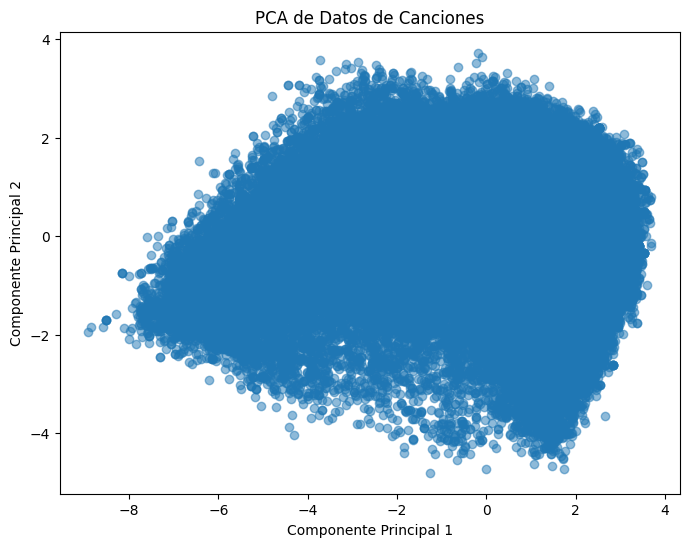

In [11]:
# Aplicar Principal Component Analysis (PCA)
pca = PCA(n_components=2)

# Transformar los datos escalados
data_pca = pca.fit_transform(data)
data_pca_df = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])

# Visualizar los componentes principales
plt.figure(figsize=(8,6))
plt.scatter(data_pca_df['PCA1'], data_pca_df['PCA2'], alpha=0.5)
plt.title('PCA de Datos de Canciones')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()


Podemos ver una masa de puntos densa y ovalada sin separaciones claras. La interpretación con PCA es que la música es un espectro continuo ya que no es posible detectar minguna fractura en los datos. La conclusión de estos es que un modelo lineal simple (como una Regresión Logística básica sin kernel) podría tener dificultades para separar perfectamente los géneros o emociones basándose solo en 2 dimensiones.

c:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


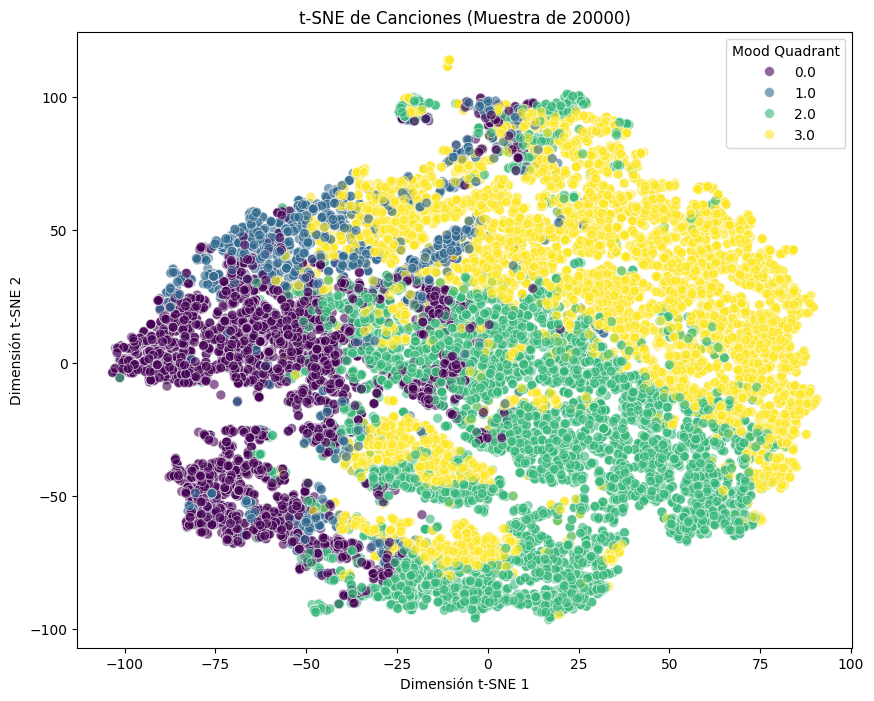

In [12]:
# 1. MUESTREO (para evitar lentitud)
N_SAMPLES = 20000
data_sample = data.sample(n=N_SAMPLES, random_state=42)

# 2. Aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init='pca', learning_rate='auto')

# Transformar los datos
cols_to_fit = [col for col in data_sample.columns if col not in ['mood_quadrant', 'mood_category']]
data_tsne = tsne.fit_transform(data_sample[cols_to_fit])

# 3. Crear DataFrame para graficar
data_tsne_df = pd.DataFrame(data_tsne, columns=['TSNE1', 'TSNE2'])

# Añadimos la información del Mood para colorear 
# Reseteamos índice para que coincida con el array generado por t-SNE
data_tsne_df['Mood'] = data_sample['mood_quadrant'].values 


# 4. Visualizar
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1', 
    y='TSNE2', 
    data=data_tsne_df, 
    hue='Mood', 
    palette='viridis', 
    alpha=0.6,
    s=50 
)

plt.title(f't-SNE de Canciones (Muestra de {N_SAMPLES})')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Mood Quadrant')
plt.show()

En este caso, sí que es posible diferenciar separaciones en los datos, agrupados de manera lógica. LLama la atención la separación en el medio del gráfico donde a la izquierda quedan los tonos oscuros (morado y azul correspondientes a las energías sad y calm) y a la derecha tonos claros (verde y amarillo correspondiente con las energías angry y happy). Esto nos dice que la Energía es una de las variables más dominantes para agrupar canciones.

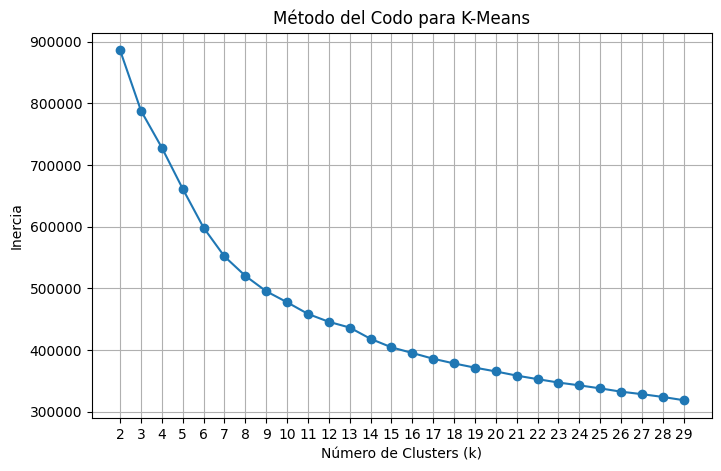

In [13]:
# Aplicar el método del codo para determinar el número óptimo de clusters
inertia_values = []
K_range = range(2, 30)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled_numeric)
    inertia_values.append(kmeans.inertia_)
    
# Graficar la inercia vs número de clusters
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(K_range)
plt.grid()
plt.show()

Iniciando cálculo optimizado...
k=2, Score=0.3068
k=3, Score=0.1755
k=4, Score=0.1708
k=5, Score=0.1809
k=6, Score=0.1891
k=7, Score=0.1971
k=8, Score=0.1743
k=9, Score=0.1777
k=10, Score=0.1795
k=11, Score=0.1708
k=12, Score=0.1739
k=13, Score=0.1625
k=14, Score=0.1699
k=15, Score=0.1539
k=16, Score=0.1579
k=17, Score=0.1515
k=18, Score=0.1529
k=19, Score=0.1498
k=20, Score=0.1503
k=21, Score=0.1482
k=22, Score=0.1475
k=23, Score=0.1420
k=24, Score=0.1419
k=25, Score=0.1449
k=26, Score=0.1429
k=27, Score=0.1474
k=28, Score=0.1438
k=29, Score=0.1454


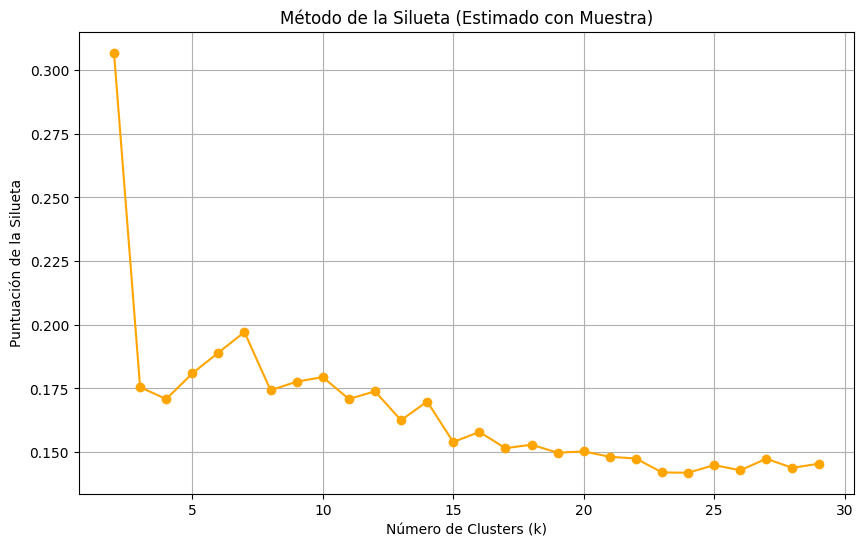

In [14]:
# Aplicar el método de la silueta para determinar el número óptimo de clusters
silhouette_scores = []
K_range = range(2, 30) 

print("Iniciando cálculo optimizado...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(data_scaled_numeric)
    silhouette_avg = silhouette_score(data_scaled_numeric, cluster_labels, sample_size=5000, random_state=42)
    silhouette_scores.append(silhouette_avg)
    print(f"k={k}, Score={silhouette_avg:.4f}") # Para que veas el progreso

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title('Método de la Silueta (Estimado con Muestra)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de la Silueta')
plt.grid()
plt.show()

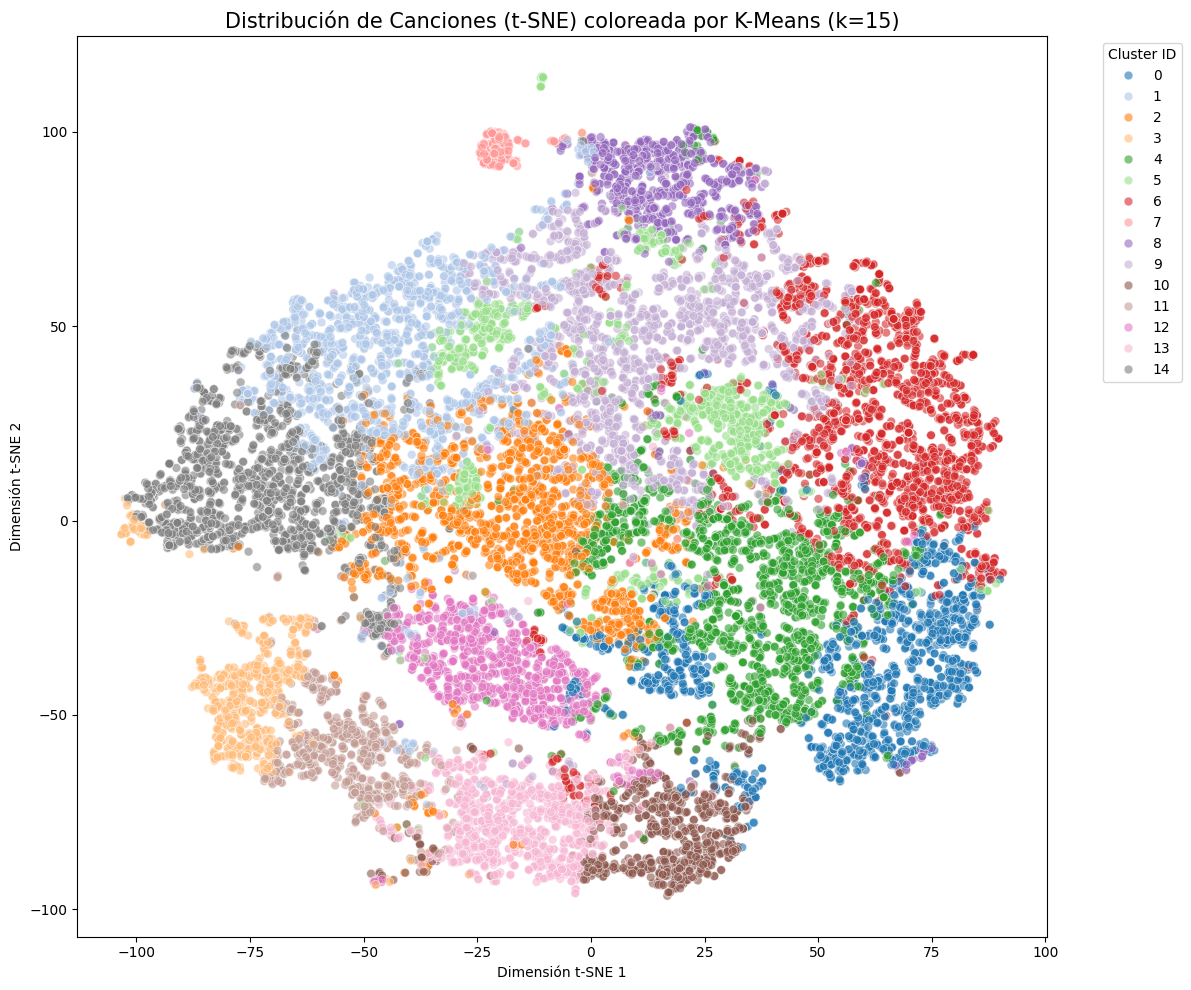

In [15]:
# 1. CONFIGURACIÓN Y MODELADO 
optimal_k = 15

# Optimizamos n_init para evitar warnings futuros y fijamos random_state
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Asignamos los clusters al dataset ORIGINAL completo
data['cluster'] = kmeans_final.fit_predict(data_scaled_numeric)


# 2. ALINEACIÓN DE DATOS 
data_tsne_df['cluster'] = data.loc[data_sample.index, 'cluster'].values
data_tsne_df['cluster'] = data_tsne_df['cluster'].astype('category')


# 3. VISUALIZACIÓN
plt.figure(figsize=(12, 10)) # Un poco más grande para K=10

sns.scatterplot(
    x='TSNE1', 
    y='TSNE2', 
    data=data_tsne_df, 
    hue='cluster',      
    palette='tab20',    
    alpha=0.6,
    s=40,              
    legend='full'
)

plt.title(f'Distribución de Canciones (t-SNE) coloreada por K-Means (k={optimal_k})', fontsize=15)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster ID')

plt.tight_layout()
plt.show()

En conjunto, la figura permite observar cómo se organizan las canciones en el espacio de similitud: grupos claramente separados sugieren segmentos musicales diferenciados, mientras que áreas con fronteras menos nítidas muestran transiciones entre estilos. Esta visualización es especialmente útil para validar la coherencia del modelo, detectar solapamientos entre clústeres y comprender mejor la estructura del catálogo.

## Conclusión

En el sector musical, el clustering aporta un valor significativo. Puede utilizarse para mejorar sistemas de recomendación al agrupar canciones con perfiles sonoros afines, optimizar la creación de playlists automáticas, segmentar audiencias según gustos reales, o incluso apoyar decisiones de marketing musical basadas en patrones de consumo. También resulta útil para A&R y análisis de tendencias, ya que permite identificar nichos emergentes, similitudes entre artistas y zonas del catálogo donde existe saturación o falta de oferta. En definitiva, el clustering ayuda a transformar grandes volúmenes de datos musicales en información accionable y orientada a negocio.